
## Graph visualisation algorithms from the NetworkX Python library
#### Aleksander Wojsz, Stanisław Bitner


**Contents**:
1. Definitions
2. Examples
3. Spring layout implementation
4. Arf layout implementation
5. Spectral layout implementation

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt # Plots

import numpy as np
from matplotlib.animation import FuncAnimation
from copy import deepcopy

In [ ]:
# G - NetworkX graph
# layouts - dictionary of layouts
# plots_y - numer of plots in the y-axis
# plots_x - number of plots in the x-axis
def render(G, layouts, plots_y=1, plots_x=1, with_labels=True):
    plt.figure(figsize=(15, 15))
    for i, (layout_name, layout_func) in enumerate(layouts.items()):
        plt.subplot(plots_y, plots_x, i + 1)
        plt.title(layout_name)
        nx.draw(G, layout_func(G), with_labels=with_labels)

    plt.show()

# Definitions


##### 1. **Spring Layout (nx.spring_layout)**
- Nodes repel each other like magnets.  
- Edges behave like springs, pulling nodes closer together.

---

##### 2. **Arf Layout (nx.arf_layout)**

The ARF layout aims to fix some problems encountered with the Spring Layout.



**Issues with Spring Layout:**

> Too many nodes are packed into too little space. Unfortunately, the highly connected nodes — which are often the most important in network analysis — are the ones affected.  
> Additionally, the layout space is used inefficiently, with large empty areas and overcrowded regions. A more even node distribution would also make labeling easier.  
> Also, nodes connected by an edge should be drawn close to each other. There are two reasons for this: First, long edges are difficult for humans to follow. Second, the shorter the edge, the lower the chance of crossing another edge.


![img.png](https://drive.google.com/uc?id=1mcyqEftt1SIXAXRmLAVMtpwcvv47AbyZ)


**Solution:**

The ARF model also balances two forces: an **A**ttractive and a **R**epulsive **F**orce.

In Spring Layout, loosely connected clusters are pushed too far apart by excessive repulsion, while highly connected clusters suffer from congestion due to insufficient repulsion. ARF addresses these issues by changing the way of calculating repulsive force.

Additionally, ARF takes into account changes in graph size by scaling the repulsive force based on the square root of the number of nodes $\sqrt{|V|}$.

[Source](https://sci-hub.ru/10.1142/S0129183107011558)

---

##### 3. **Kamada-Kawai Layout (nx.kamada_kawai_layout)**  

Apart from the spring system, it has optimal distances between the vertices of the graph that it tries to achieve

$
\text{Cost} = \sum_{i=1}^{n-1} \sum_{j=i+1}^{n} \frac{1}{2} k_{ij} \left( \|x_i - x_j\| - l_{ij} \right)^2
$

$k_{ij}$ = strength of the spring connecting vertices $(i, j)$. It depends on the distance between the vertices.

$l_{ij}$ = desired on-screen length in straight line between $i,j$. If not specified, it is equal to the length of the shortest path from node $i$ to node $j$.

Gradient descent can be used to minimize the energy

[source](https://coursepages2.tuni.fi/mttts17/wp-content/uploads/sites/136/2020/04/drv_2020_lecture13.pdf)

---

##### 4. **Spectral Layout (nx.spectral_layout)**  

It calculates the Laplacian matrix [pl - macierz laplasjanu]. It computes its eigenvalues and corresponding eigenvectors. It uses the values in the eigenvectors as the coordinates of the vertices.

![Laplacian Matrix](https://drive.google.com/uc?id=1aglUFvQf4I31vph_GURnPwwUD2thE6bH)

[source](https://en.wikipedia.org/wiki/Laplacian_matrix)

---

##### 5. **Circular Layout (nx.circular_layout)**  
   All nodes are placed at equal distances along a circle.

---

##### 6. **Shell Layout (nx.shell_layout)**  
   Nodes are evenly distributed along concentric circles, with all circles having a common center. The assignment of nodes to circles is done manually.

---

##### 7. **Spiral Layout (nx.spiral_layout)**  
   Nodes are arranged in a spiral.

---

##### 8. **Planar Layout (nx.planar_layout)**  
   If possible, ensures no edges no edges overlap.




# Examples


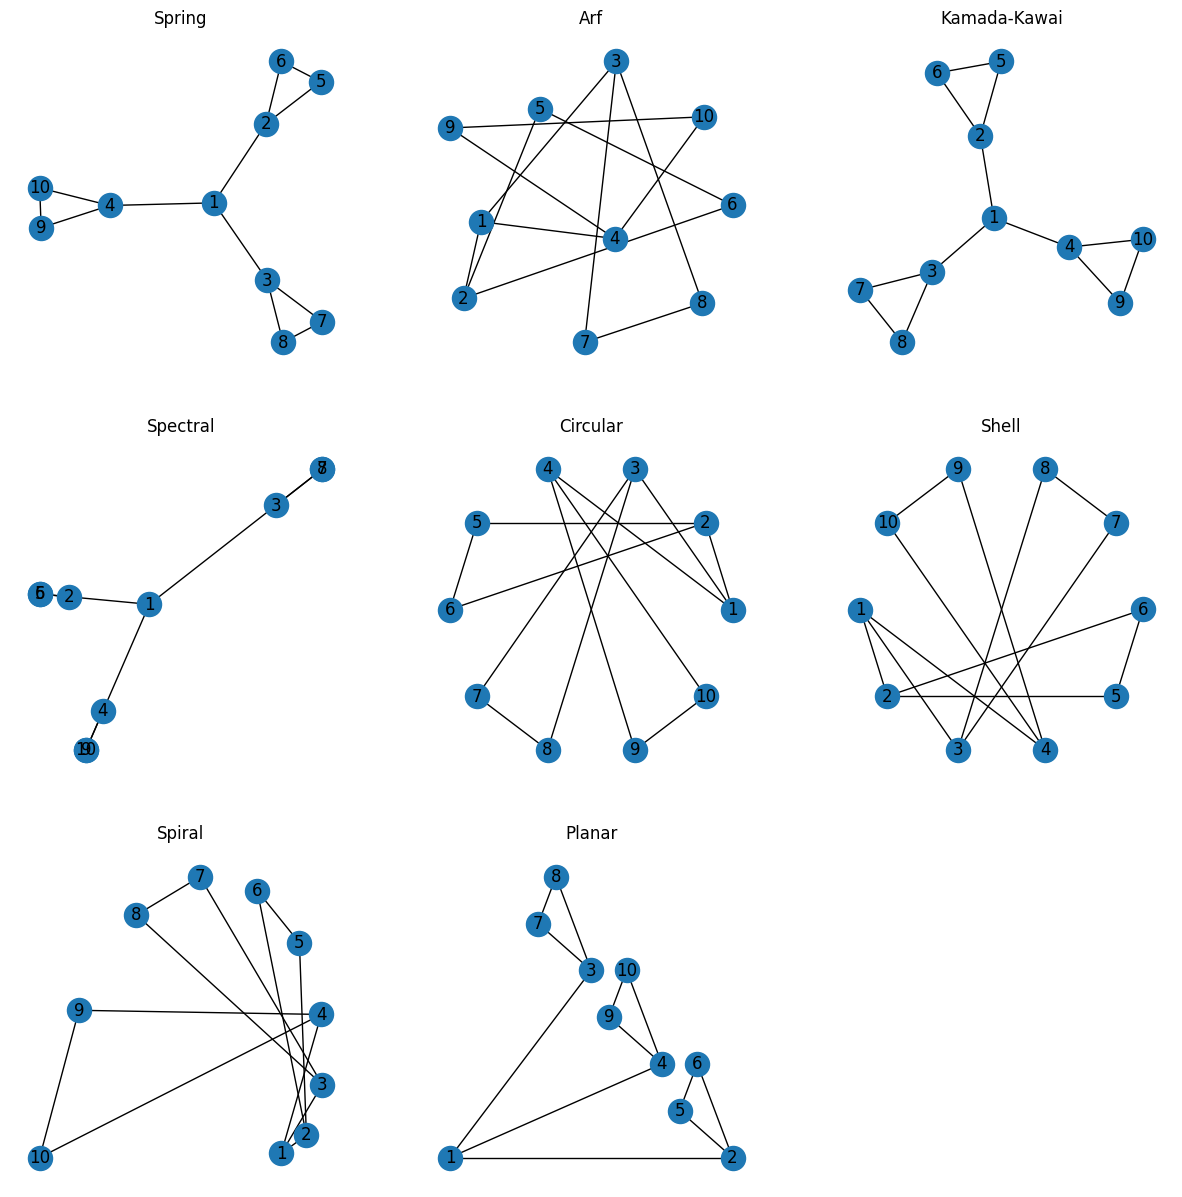

In [ ]:
layouts = {
    'Spring': nx.spring_layout,
    'Arf': nx.arf_layout,
    'Kamada-Kawai': nx.kamada_kawai_layout,
    'Spectral': nx.spectral_layout,
    'Circular': nx.circular_layout,
    'Shell': nx.shell_layout,
    'Spiral': nx.spiral_layout,
    'Planar': nx.planar_layout,
}

G = nx.Graph()
edges = [(1, 2), (1, 3), (1, 4), (2, 5), (2, 6), (3, 7), (3, 8), (4, 9), (4, 10), (5, 6), (7, 8), (9, 10)]
G.add_edges_from(edges)

render(G, layouts, 3, 3)

An example of **shell layout**

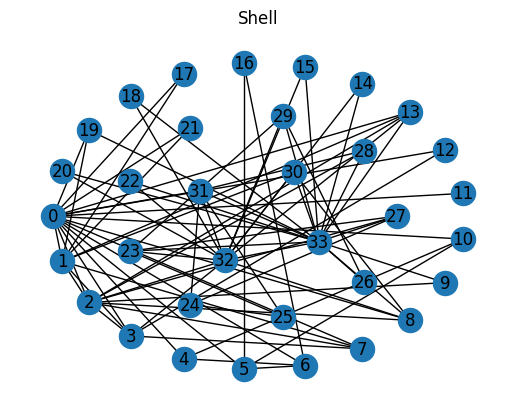

In [ ]:
shells = [np.arange(30, 34), np.arange(21, 30),  np.arange(0, 21)] # [inner layer, middle layer, outer layer]
plt.title("Shell")
nx.draw(nx.karate_club_graph(), nx.shell_layout(G, shells), with_labels=True)

An example of **kamada-kawai layout**

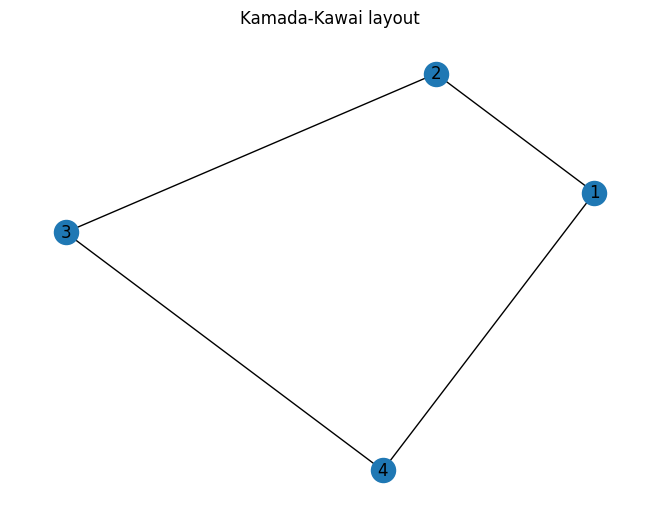

In [ ]:
G = nx.Graph()
G.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1)])
dist = {
    1: {2: 0.5, 3: 1.0, 4: 1.0},
    2: {1: 0.5, 3: 1.0, 4: 1.0},
    3: {1: 1.0, 2: 1.0, 4: 1.0},
    4: {1: 1.0, 2: 1.0, 3: 1.0}
}

# 1 - 2
# |   |
# 3 - 4

pos = nx.kamada_kawai_layout(G, dist=dist)
nx.draw(G, pos, with_labels=True)
plt.title("Kamada-Kawai layout")
plt.show()


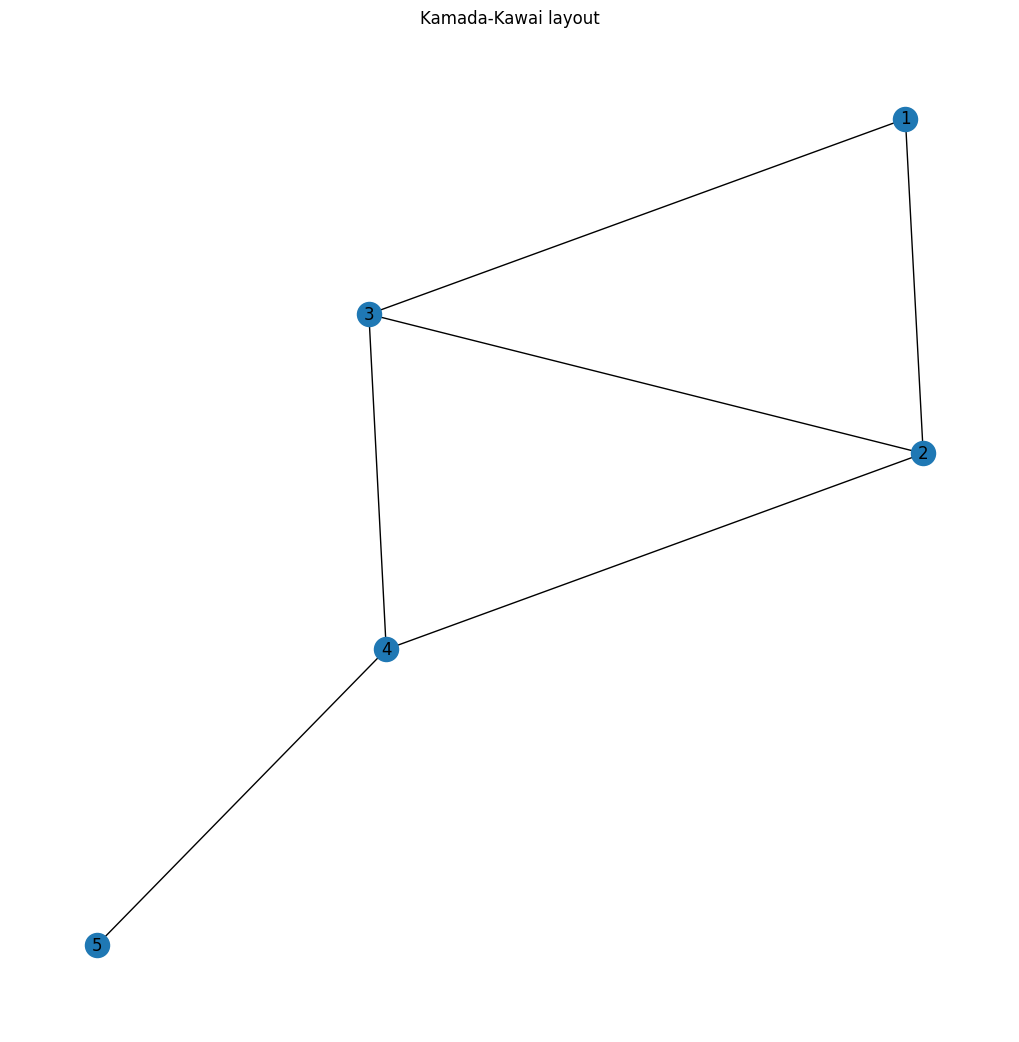

In [ ]:
G = nx.Graph()
edges = [(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 5)]
G.add_edges_from(edges)

# We did not specify the preferred distances,
# so the distance will be the length of the shortest path to a given vertex
pos = nx.kamada_kawai_layout(G)
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True)

plt.title("Kamada-Kawai layout")
plt.show()

# Spring layout implementation

In [ ]:
def spring_layout_custom(G, num_iterations, learning_rate=0.01):

    # At first, all coordinates are random values in range [0, 1)
    coordinates = {node: np.random.rand(2) for node in G.nodes()}

    animation_coordinates = [deepcopy(coordinates)]

    for _ in range(num_iterations):
        force = {node: [0, 0] for node in G.nodes()}

        # Repulsive force between nodes
        for node in G.nodes():
            for other_node in G.nodes():
                if node != other_node:
                    coordinates_diff = coordinates[node] - coordinates[other_node]
                    distance = np.sqrt(np.sum(coordinates_diff ** 2)) # Euclidean distance = sqrt((x_1 - x_2)^2 + (y_1 - y_2)^2)
                    if distance > 0:
                        force[node] += coordinates_diff / np.power(distance, 2) # Coulomb's law. Similarly to magnets, force is inversely proportional to the distance squared

        # Attractive forces of edges
        for edge in G.edges():
            src_node = edge[0]
            dst_node = edge[1]
            coordinates_diff = coordinates[src_node] - coordinates[dst_node]
            force[src_node] -= coordinates_diff # Hooke's law: the force is proportional to the extension
            force[dst_node] += coordinates_diff

        # Update positions
        for node in G.nodes():
            coordinates[node] += force[node] * learning_rate

        learning_rate *= 0.99
        animation_coordinates.append(deepcopy(coordinates))

    return animation_coordinates

def update(frame, G, positions, plot):
    plot.clear()
    plot.set_title(f"Spring layout. Iteration {frame}")
    nx.draw(G, positions[frame], with_labels=True)

def run_spring_layout_custom(G, num_iterations=50, learning_rate=0.01):
    positions = spring_layout_custom(G, num_iterations, learning_rate)

    fig, plot = plt.subplots(figsize=(10, 10))
    ani = FuncAnimation(fig, update, fargs=(G, positions, plot), frames=len(positions), repeat=True, interval=350)
    ani.save("notebook_assets/animation_spring.gif")


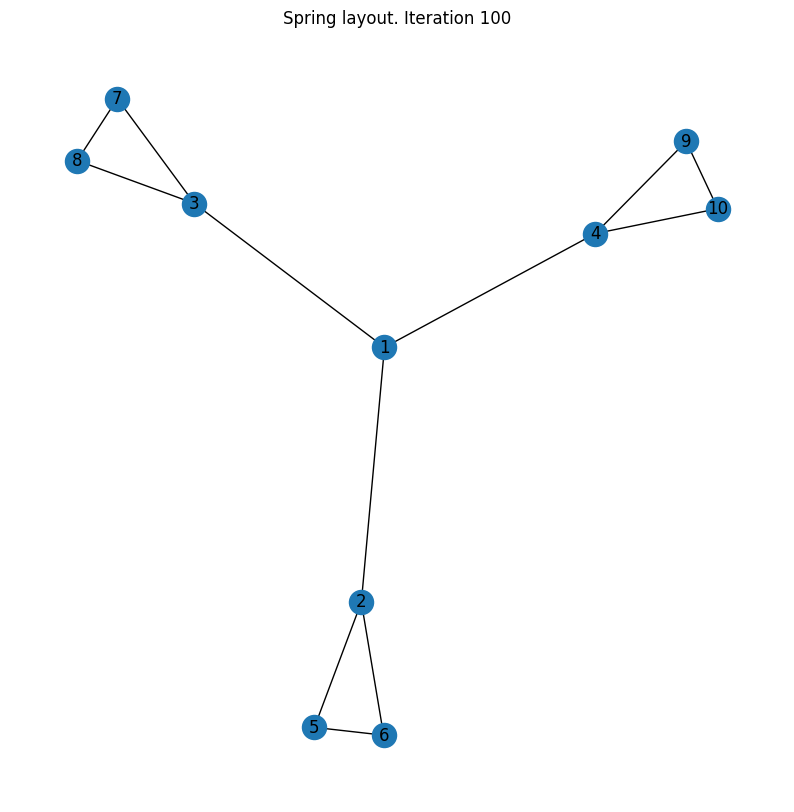

In [ ]:
G = nx.Graph()
edges = [(1, 2), (1, 3), (1, 4), (2, 5), (2, 6), (3, 7), (3, 8), (4, 9), (4, 10), (5, 6), (7, 8), (9, 10)]
G.add_edges_from(edges)

run_spring_layout_custom(G, num_iterations=100, learning_rate=0.3)

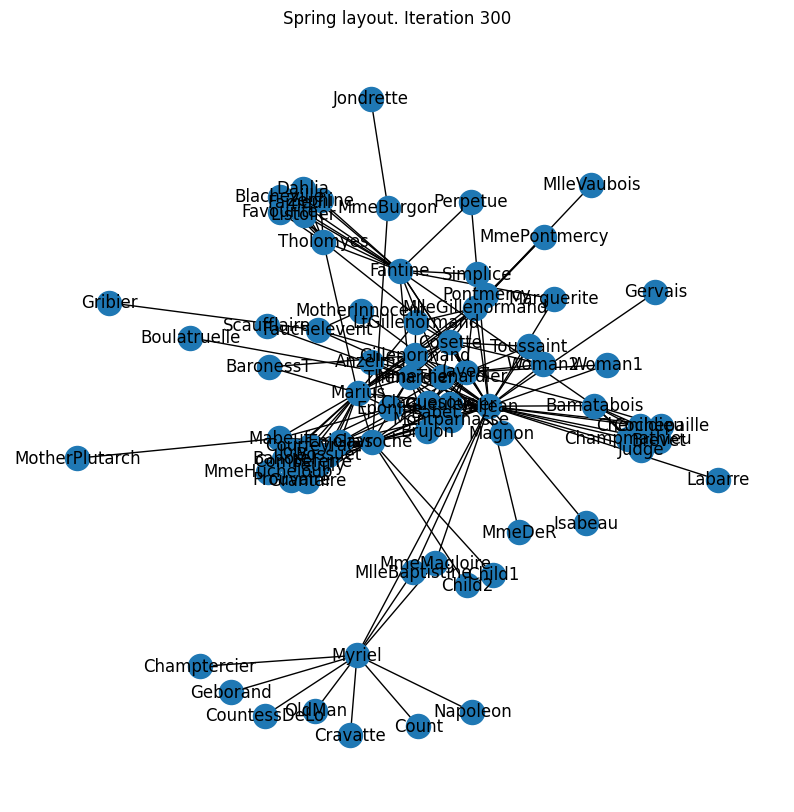

In [ ]:
run_spring_layout_custom(nx.les_miserables_graph(), num_iterations=300, learning_rate=0.01)

![animation](https://drive.google.com/uc?id=1vLaOlgPUiZ0MokGAR3LTfxWT2kwAScfc)

Now, let's compare our result to that of NetworkX

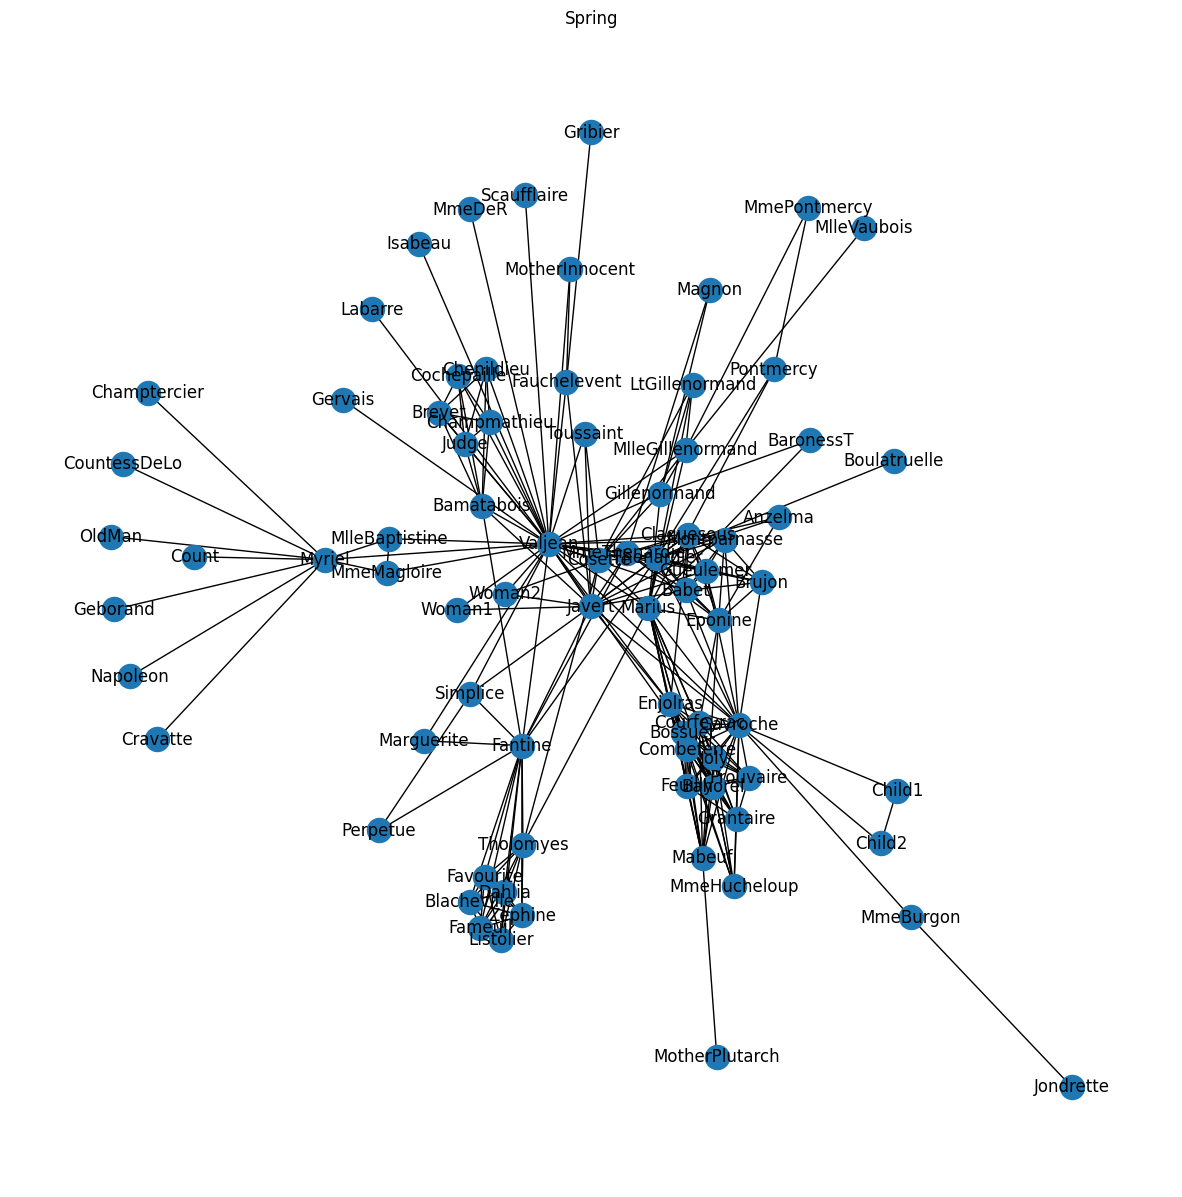

In [ ]:
layouts = {
    'Spring': nx.spring_layout,
}

render(nx.les_miserables_graph(), layouts, plots_y=1, plots_x=1)

# ARF layout implementation

In [ ]:
def arf_layout_custom(G, max_iter, learning_rate):

    a = 1.5  # Spring force constant for connected nodes (must be greater than 1)
    b = 1.5  # Scaling factor for the repulsive force

    # At first, nodes position is random
    coordinates = {i: np.random.rand(2) for i in G.nodes()}
    animation_coordinates = [deepcopy(coordinates)]

    for iteration in range(max_iter):

        new_coordinates = {}
        for node in G.nodes:
            node_coords = np.array(coordinates[node])
            force = np.zeros(2)

            for other_node in G.nodes():
                if node != other_node:
                    other_node_coords = np.array(coordinates[other_node])
                    distance = np.linalg.norm(node_coords - other_node_coords)

                    if distance > 0:
                        if G.has_edge(node, other_node):
                            K = a
                        else: # Not connected vertices also repel each other (but the force is weaker than for the existing edge)
                            K = 1.0

                        force += K * (node_coords - other_node_coords) # Edges force
                        force -= b * np.sqrt(len(G)) / distance * (node_coords - other_node_coords) # Nodes force

            new_coordinates[node] = coordinates[node] + force * learning_rate

        coordinates = new_coordinates
        learning_rate *= 0.99
        animation_coordinates.append(deepcopy(coordinates))

    return animation_coordinates

def update(frame, G, positions, plot):
    plot.clear()
    plot.set_title(f"Arf layout. Iteration {frame}")
    nx.draw(G, positions[frame], with_labels=False)

def run_spring_layout_custom(G, num_iterations, learning_rate):
    positions = arf_layout_custom(G, num_iterations, learning_rate)

    fig, plot = plt.subplots(figsize=(10, 10))
    ani = FuncAnimation(fig, update, fargs=(G, positions, plot), frames=len(positions), repeat=True, interval=400)
    ani.save("notebook_assets/animation_arf.gif")

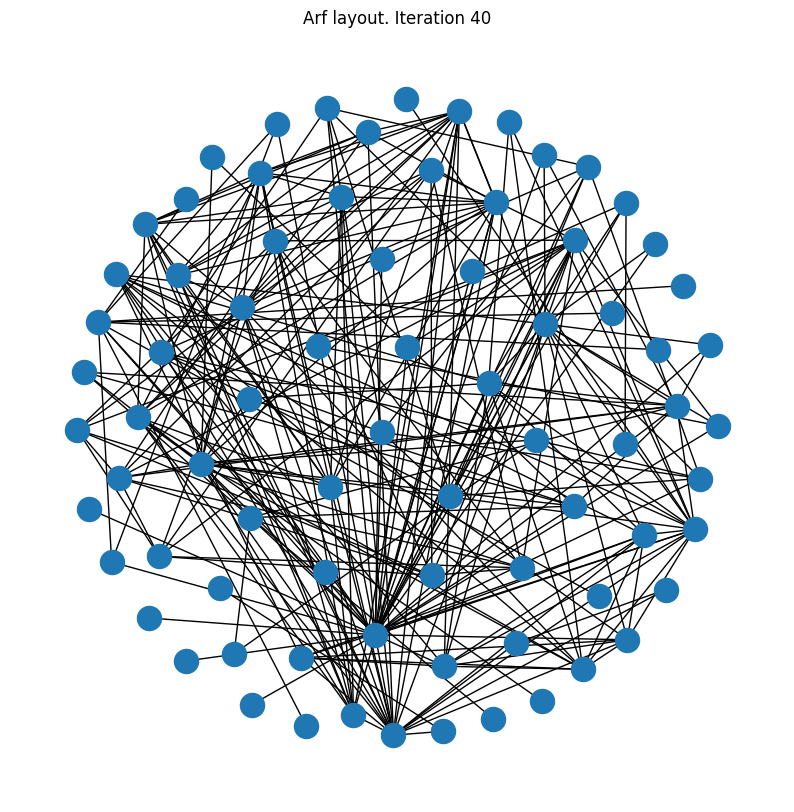

In [ ]:
run_spring_layout_custom(nx.les_miserables_graph(), num_iterations=40, learning_rate=0.0001)

![animation_art](https://drive.google.com/uc?id=1DDMaOdYPT0m9kdhtnS7UkincsVHMQsJd)

Now, let's compare our result to that of NetworkX

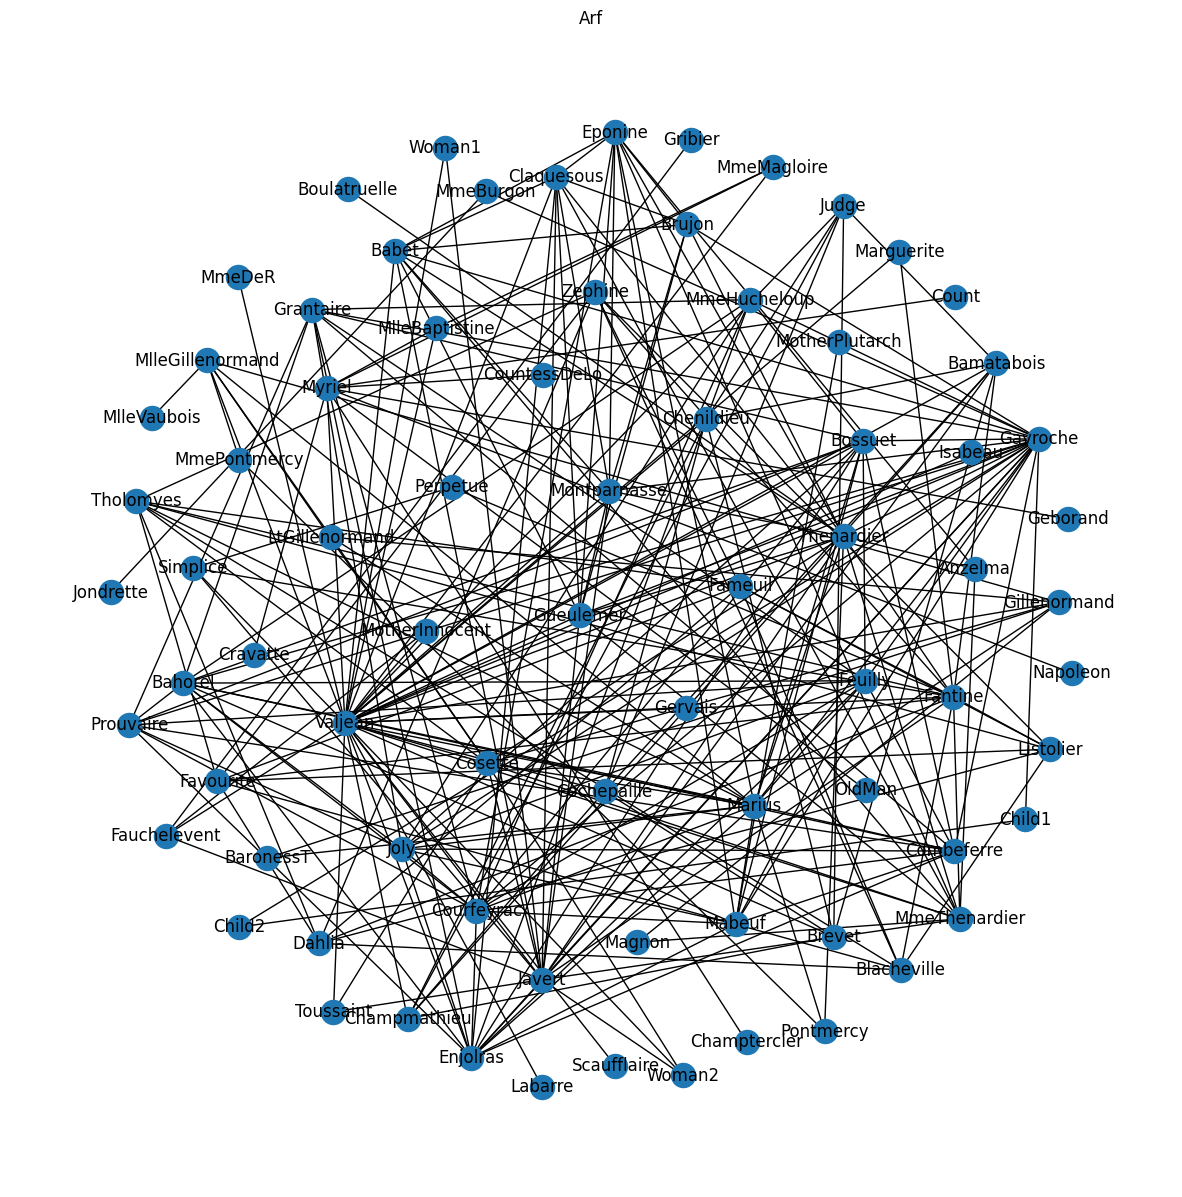

In [ ]:
layouts = {
    'Arf': nx.arf_layout,
}

render(nx.les_miserables_graph(), layouts, plots_y=1, plots_x=1)

# Spectral layout implementation

In [ ]:
def spectral_layout_custom(G):
    # Special cases
    if len(G) == 0:
        return {}
    if len(G) == 1:
        nodes = list(G.nodes())
        return {nodes[0]: np.zeros(2)}
    if len(G) == 2:
        nodes = list(G.nodes())
        return {nodes[0]: np.zeros(2), nodes[1]: np.ones(2)}

    # Adjacency matrix
    adjacency_matrix = nx.to_numpy_array(G)

    # We treat a directed graph the same as an undirected one
    if G.is_directed():
        adjacency_matrix += np.transpose(adjacency_matrix)

    # Laplacian matrix [pl - macierz laplasjanu]
    L = np.diag(adjacency_matrix.sum(axis=1)) - adjacency_matrix

    eigenvalues, eigenvectors = np.linalg.eig(L)

    # Get indices of second and third-smallest eigenvalues
    # We do not want the smallest one, as corresponding value of eigenvector is the same for every node
    indices = np.argsort(eigenvalues)[1:2+1]

    # Positions are values of eigenvectors under these indices.
    pos = np.real(eigenvectors[:, indices])

    return {n: pos[i] for i, n in enumerate(G.nodes())}

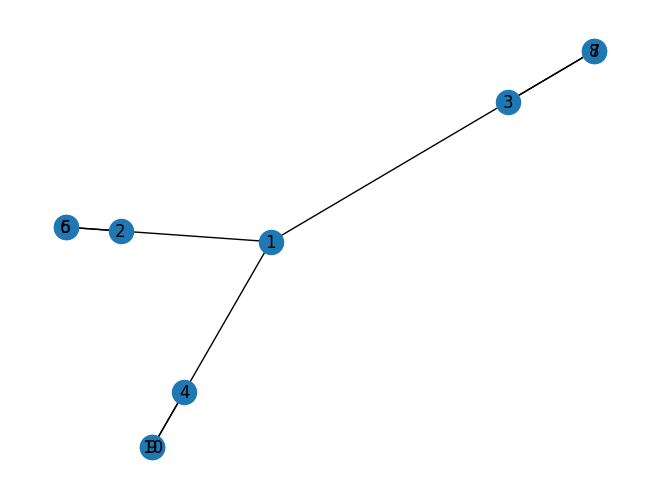

In [ ]:
G = nx.Graph()
edges = [(1, 2), (1, 3), (1, 4), (2, 5), (2, 6), (3, 7), (3, 8), (4, 9), (4, 10), (5, 6), (7, 8), (9, 10)]
G.add_edges_from(edges)

nx.draw(G, spectral_layout_custom(G), with_labels=True)
plt.show()

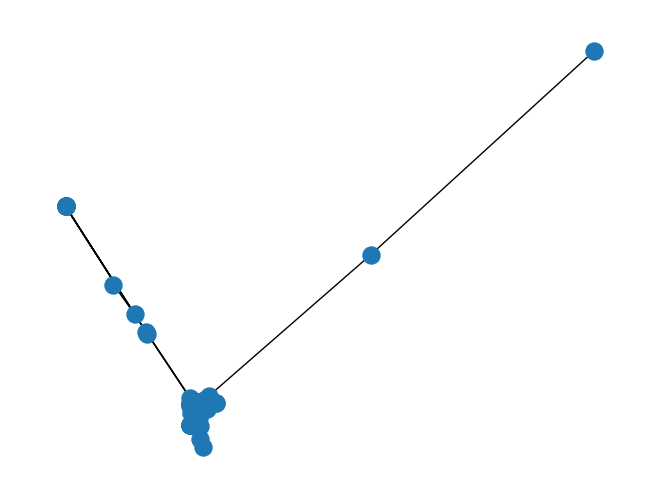

In [ ]:
G = nx.les_miserables_graph()

nx.draw(G, spectral_layout_custom(G), with_labels=False, node_size=150)
plt.show()

Now, let's compare our result to that of NetworkX

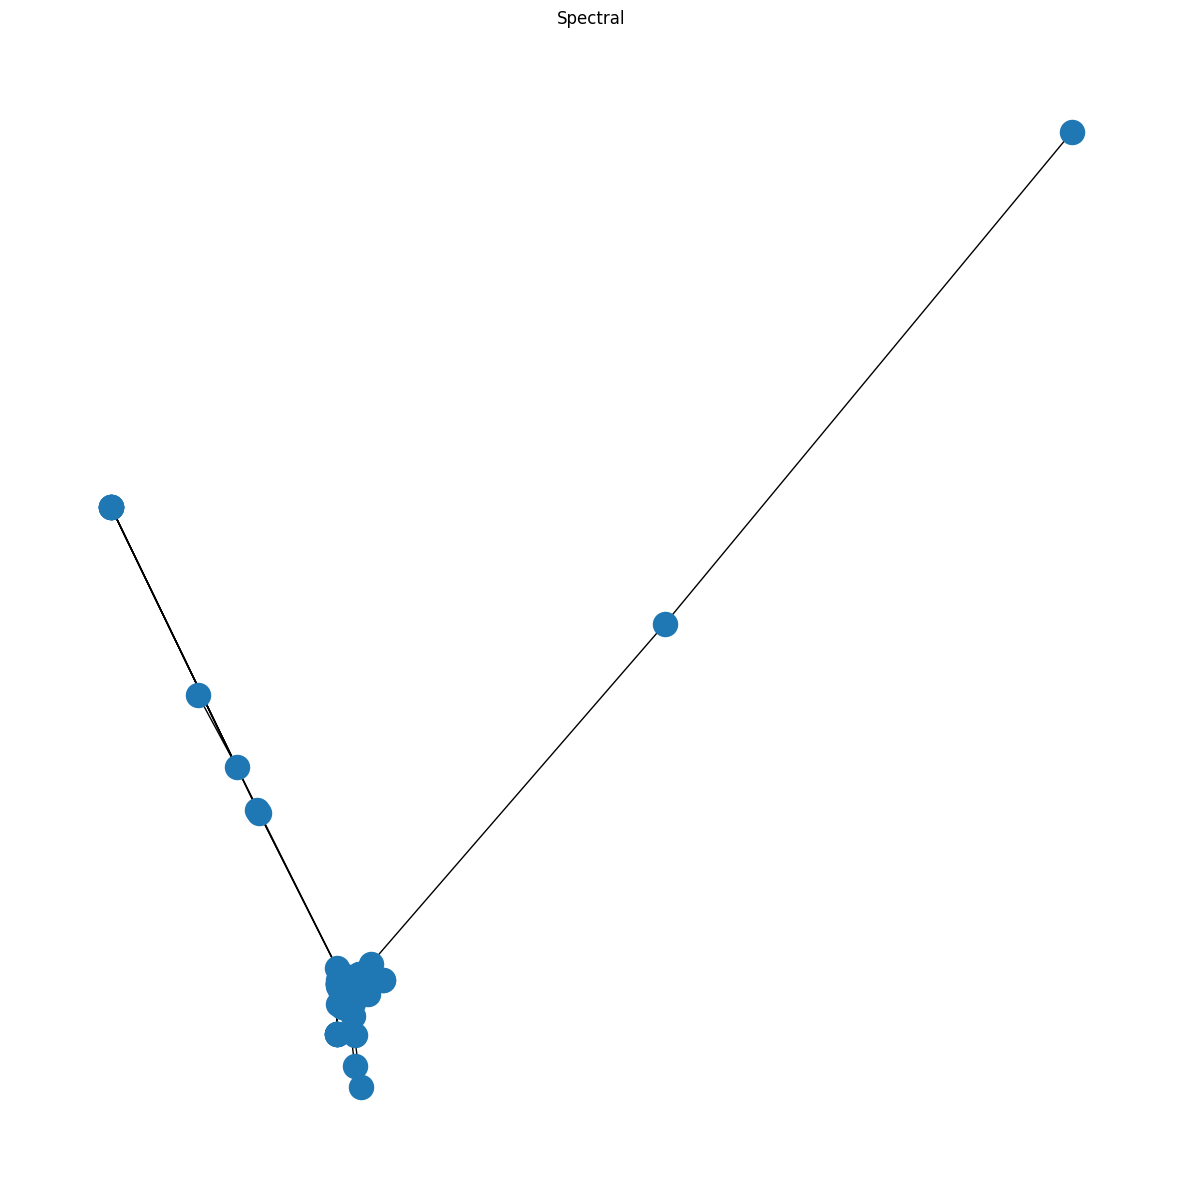

In [ ]:
layouts = {
    'Spectral': nx.spectral_layout,
}

render(nx.les_miserables_graph(), layouts, plots_y=1, plots_x=1, with_labels=False)

At the very end, we will see how the algorithms behave on a large graph (Facebook contacts - 4000 vertices - 88000 edges). Excluding Arf because overflow occurs during runtime.

In [ ]:
# File from https://snap.stanford.edu/data/ego-Facebook.html
G = nx.read_edgelist('facebook_combined.txt', create_using=nx.Graph(), nodetype=int)
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())


Text(0.5, 1.0, 'Spring')

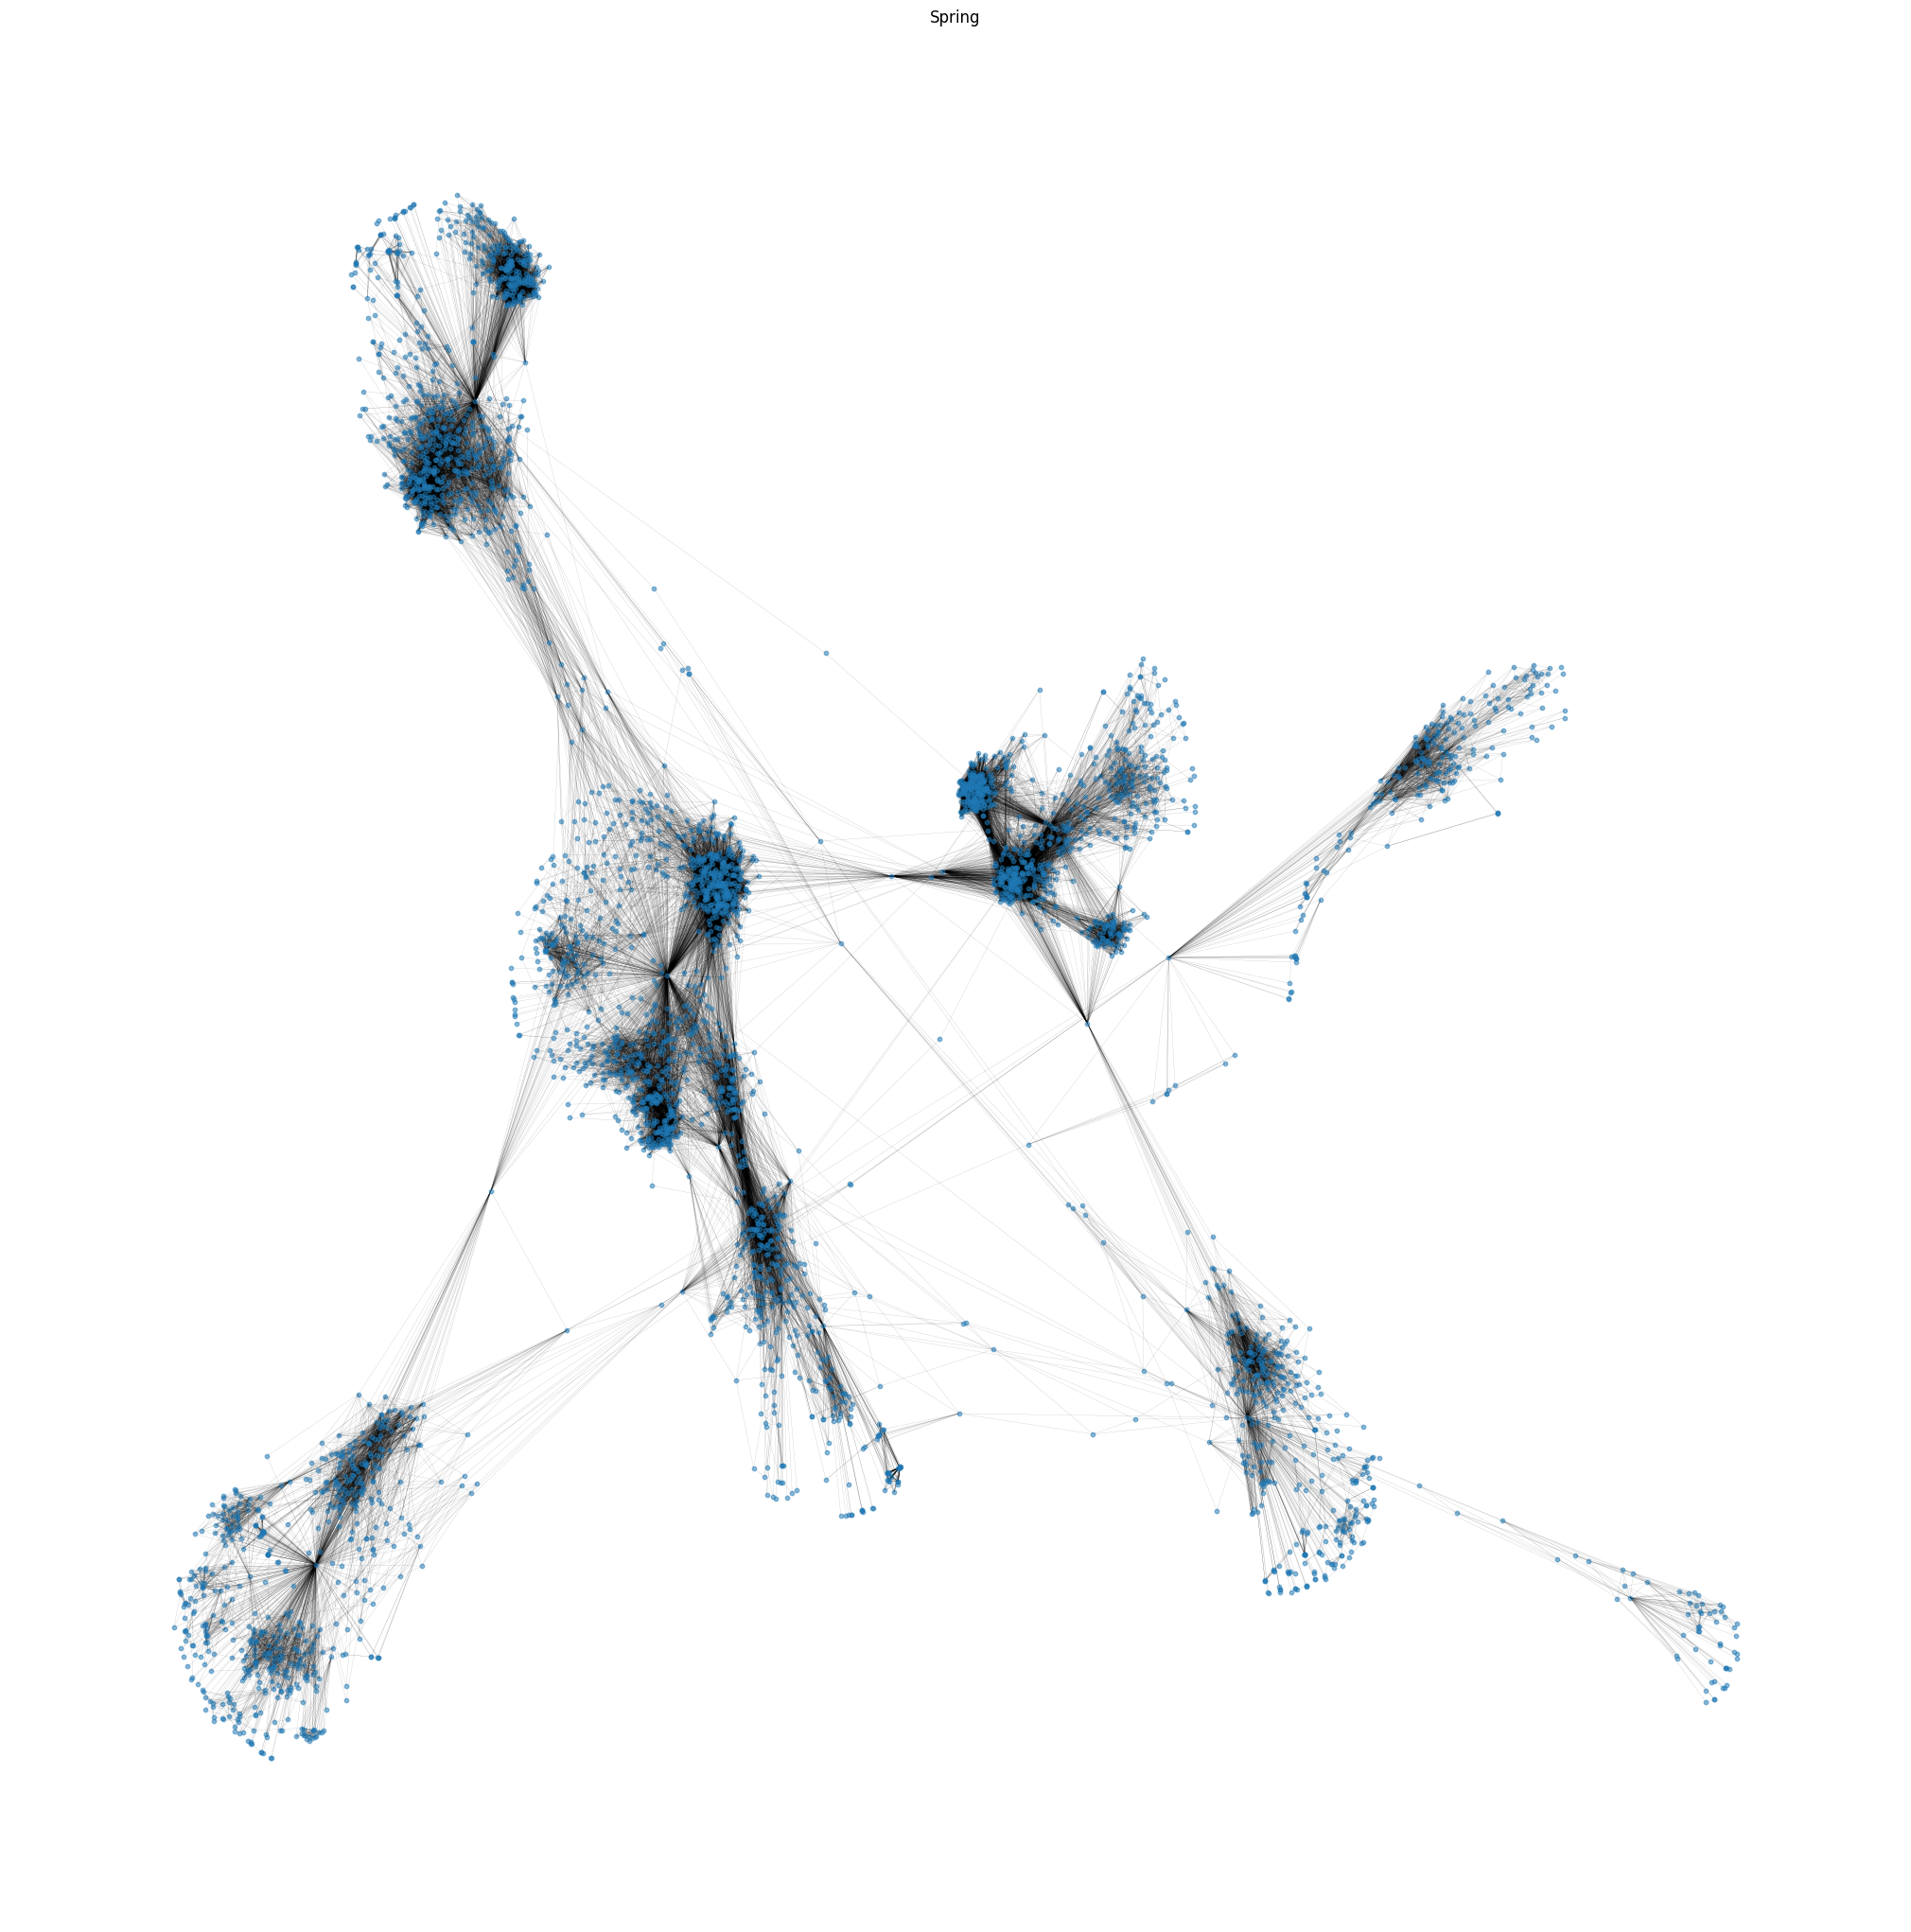

In [ ]:
plt.figure(figsize=(20, 20))
nx.draw(G, nx.spring_layout(G), with_labels=False, node_size=10, width=0.1, alpha=0.5)
plt.title("Spring")

Text(0.5, 1.0, 'Kamada-Kawai')

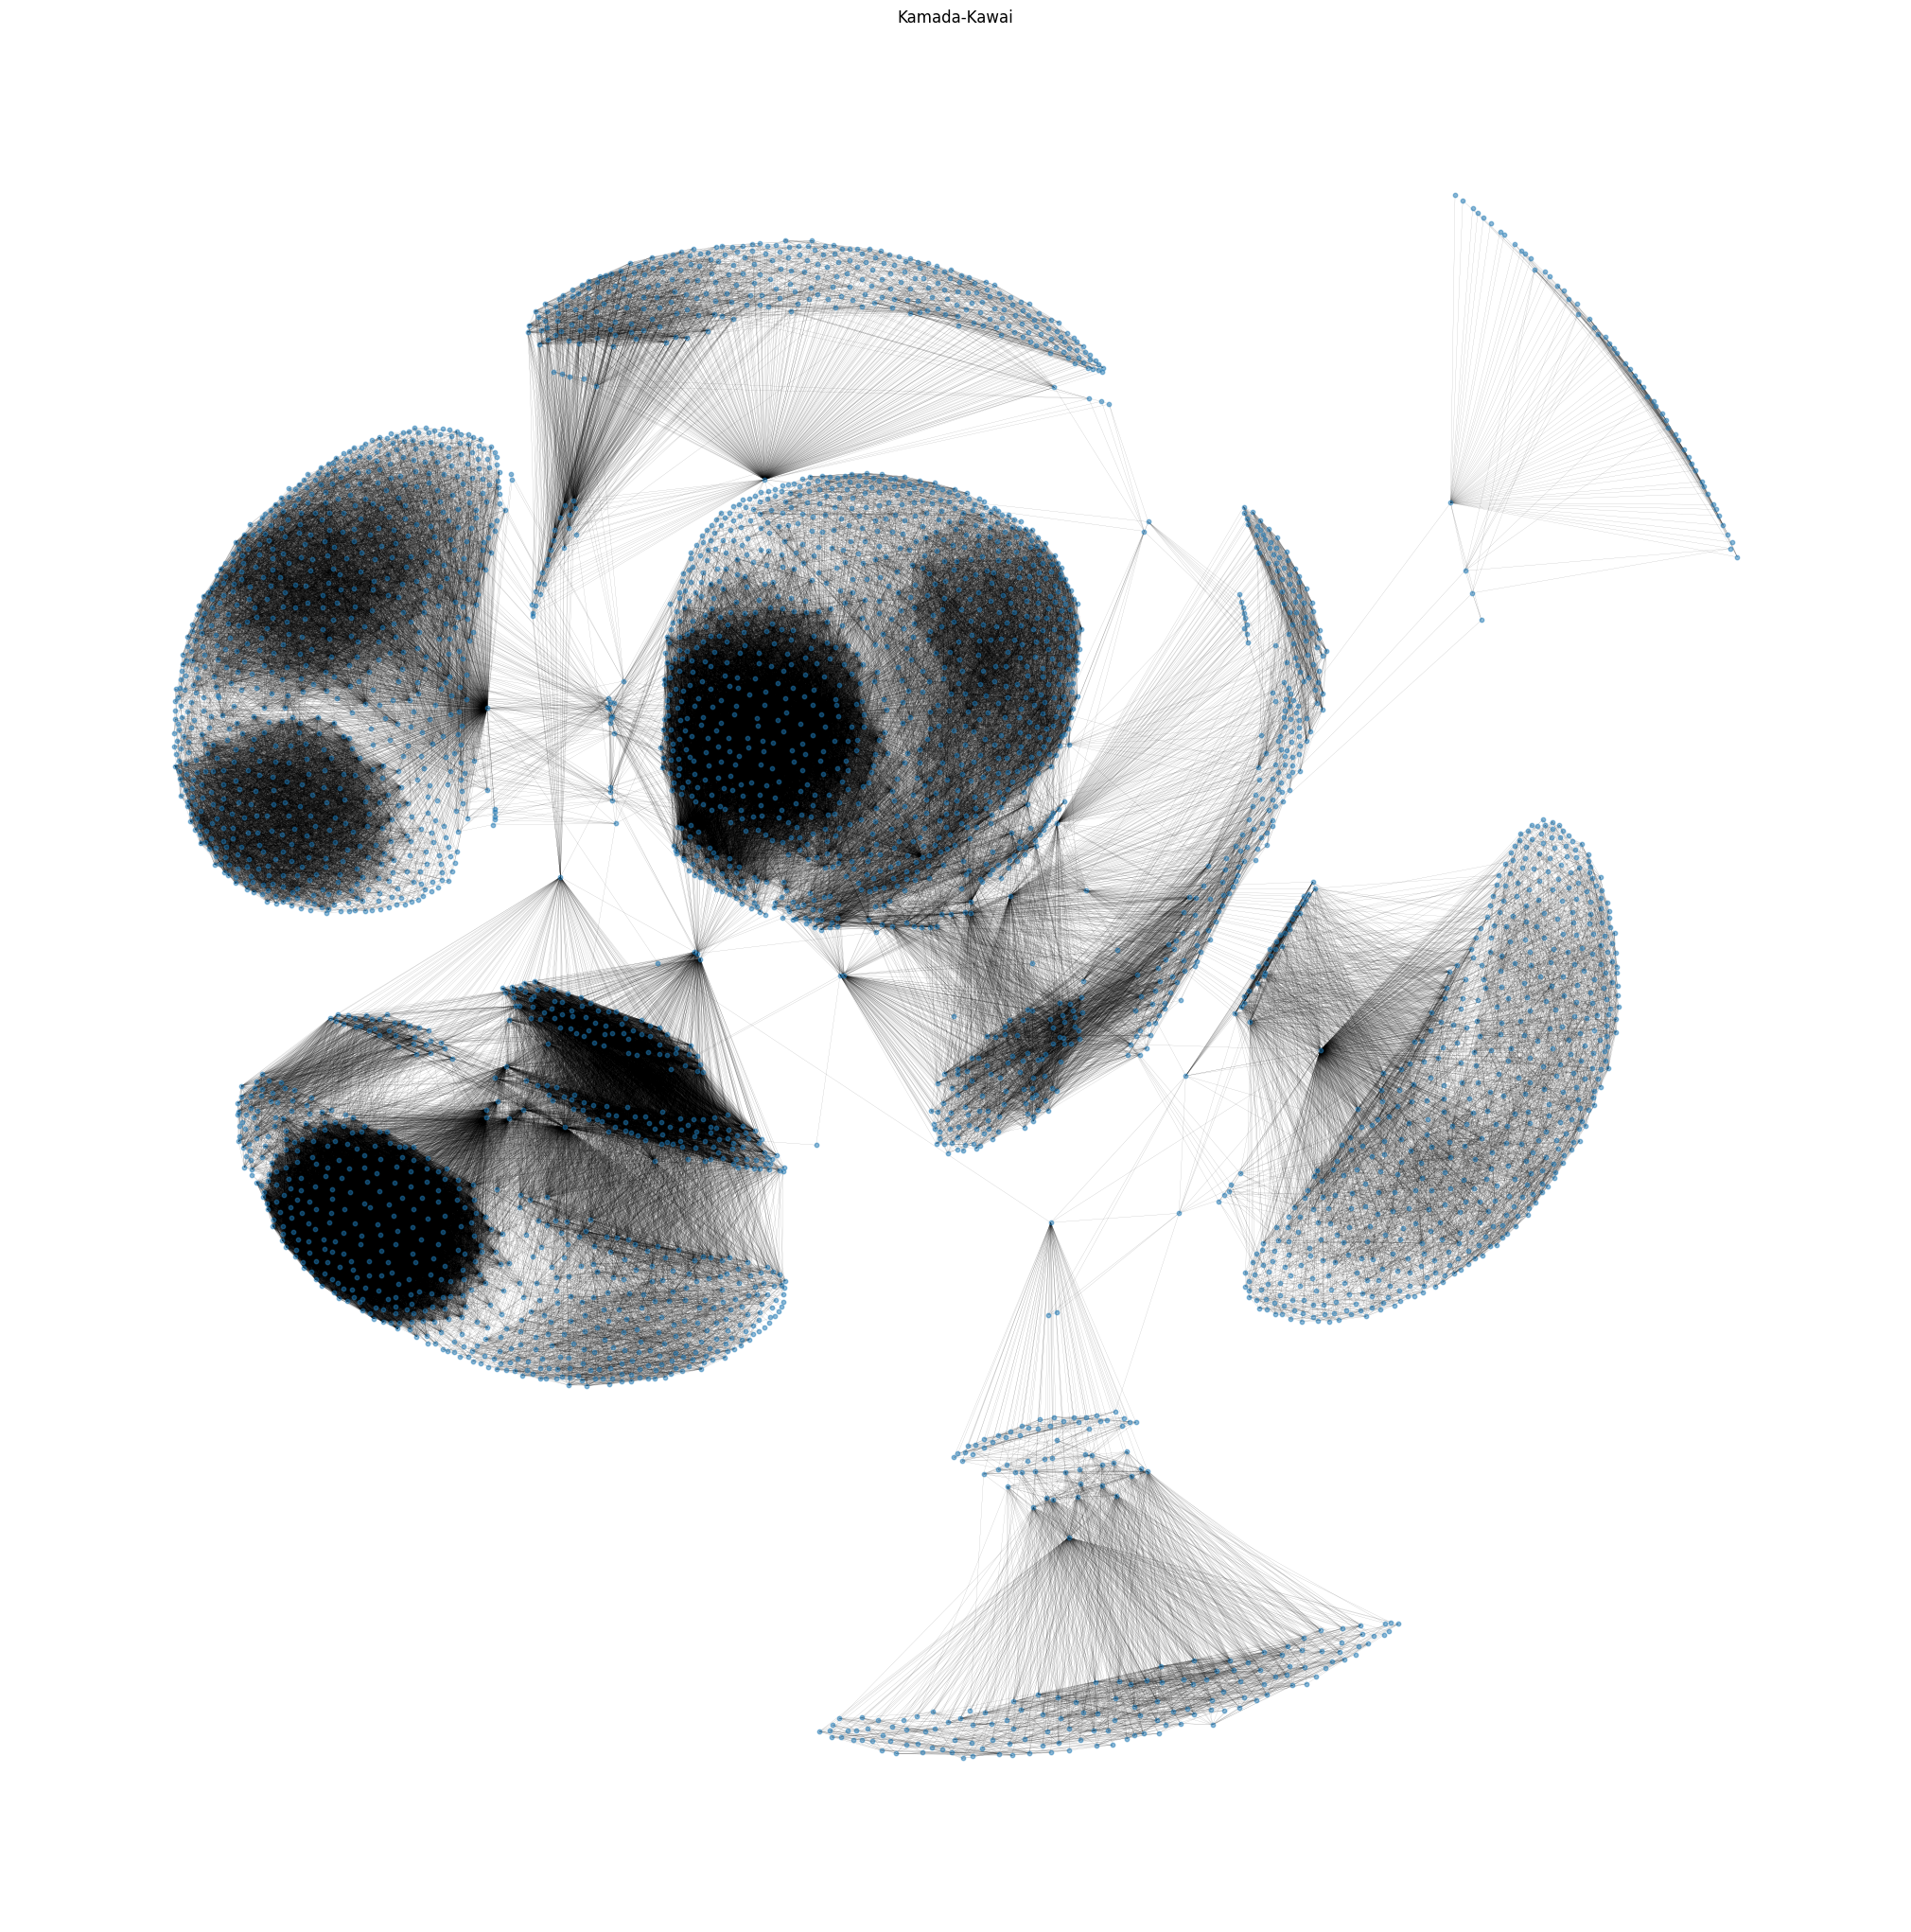

In [ ]:
plt.figure(figsize=(20, 20))
nx.draw(G, nx.kamada_kawai_layout(G), with_labels=False, node_size=10, width=0.1, alpha=0.5)
plt.title("Kamada-Kawai")


Text(0.5, 1.0, 'Spectral')

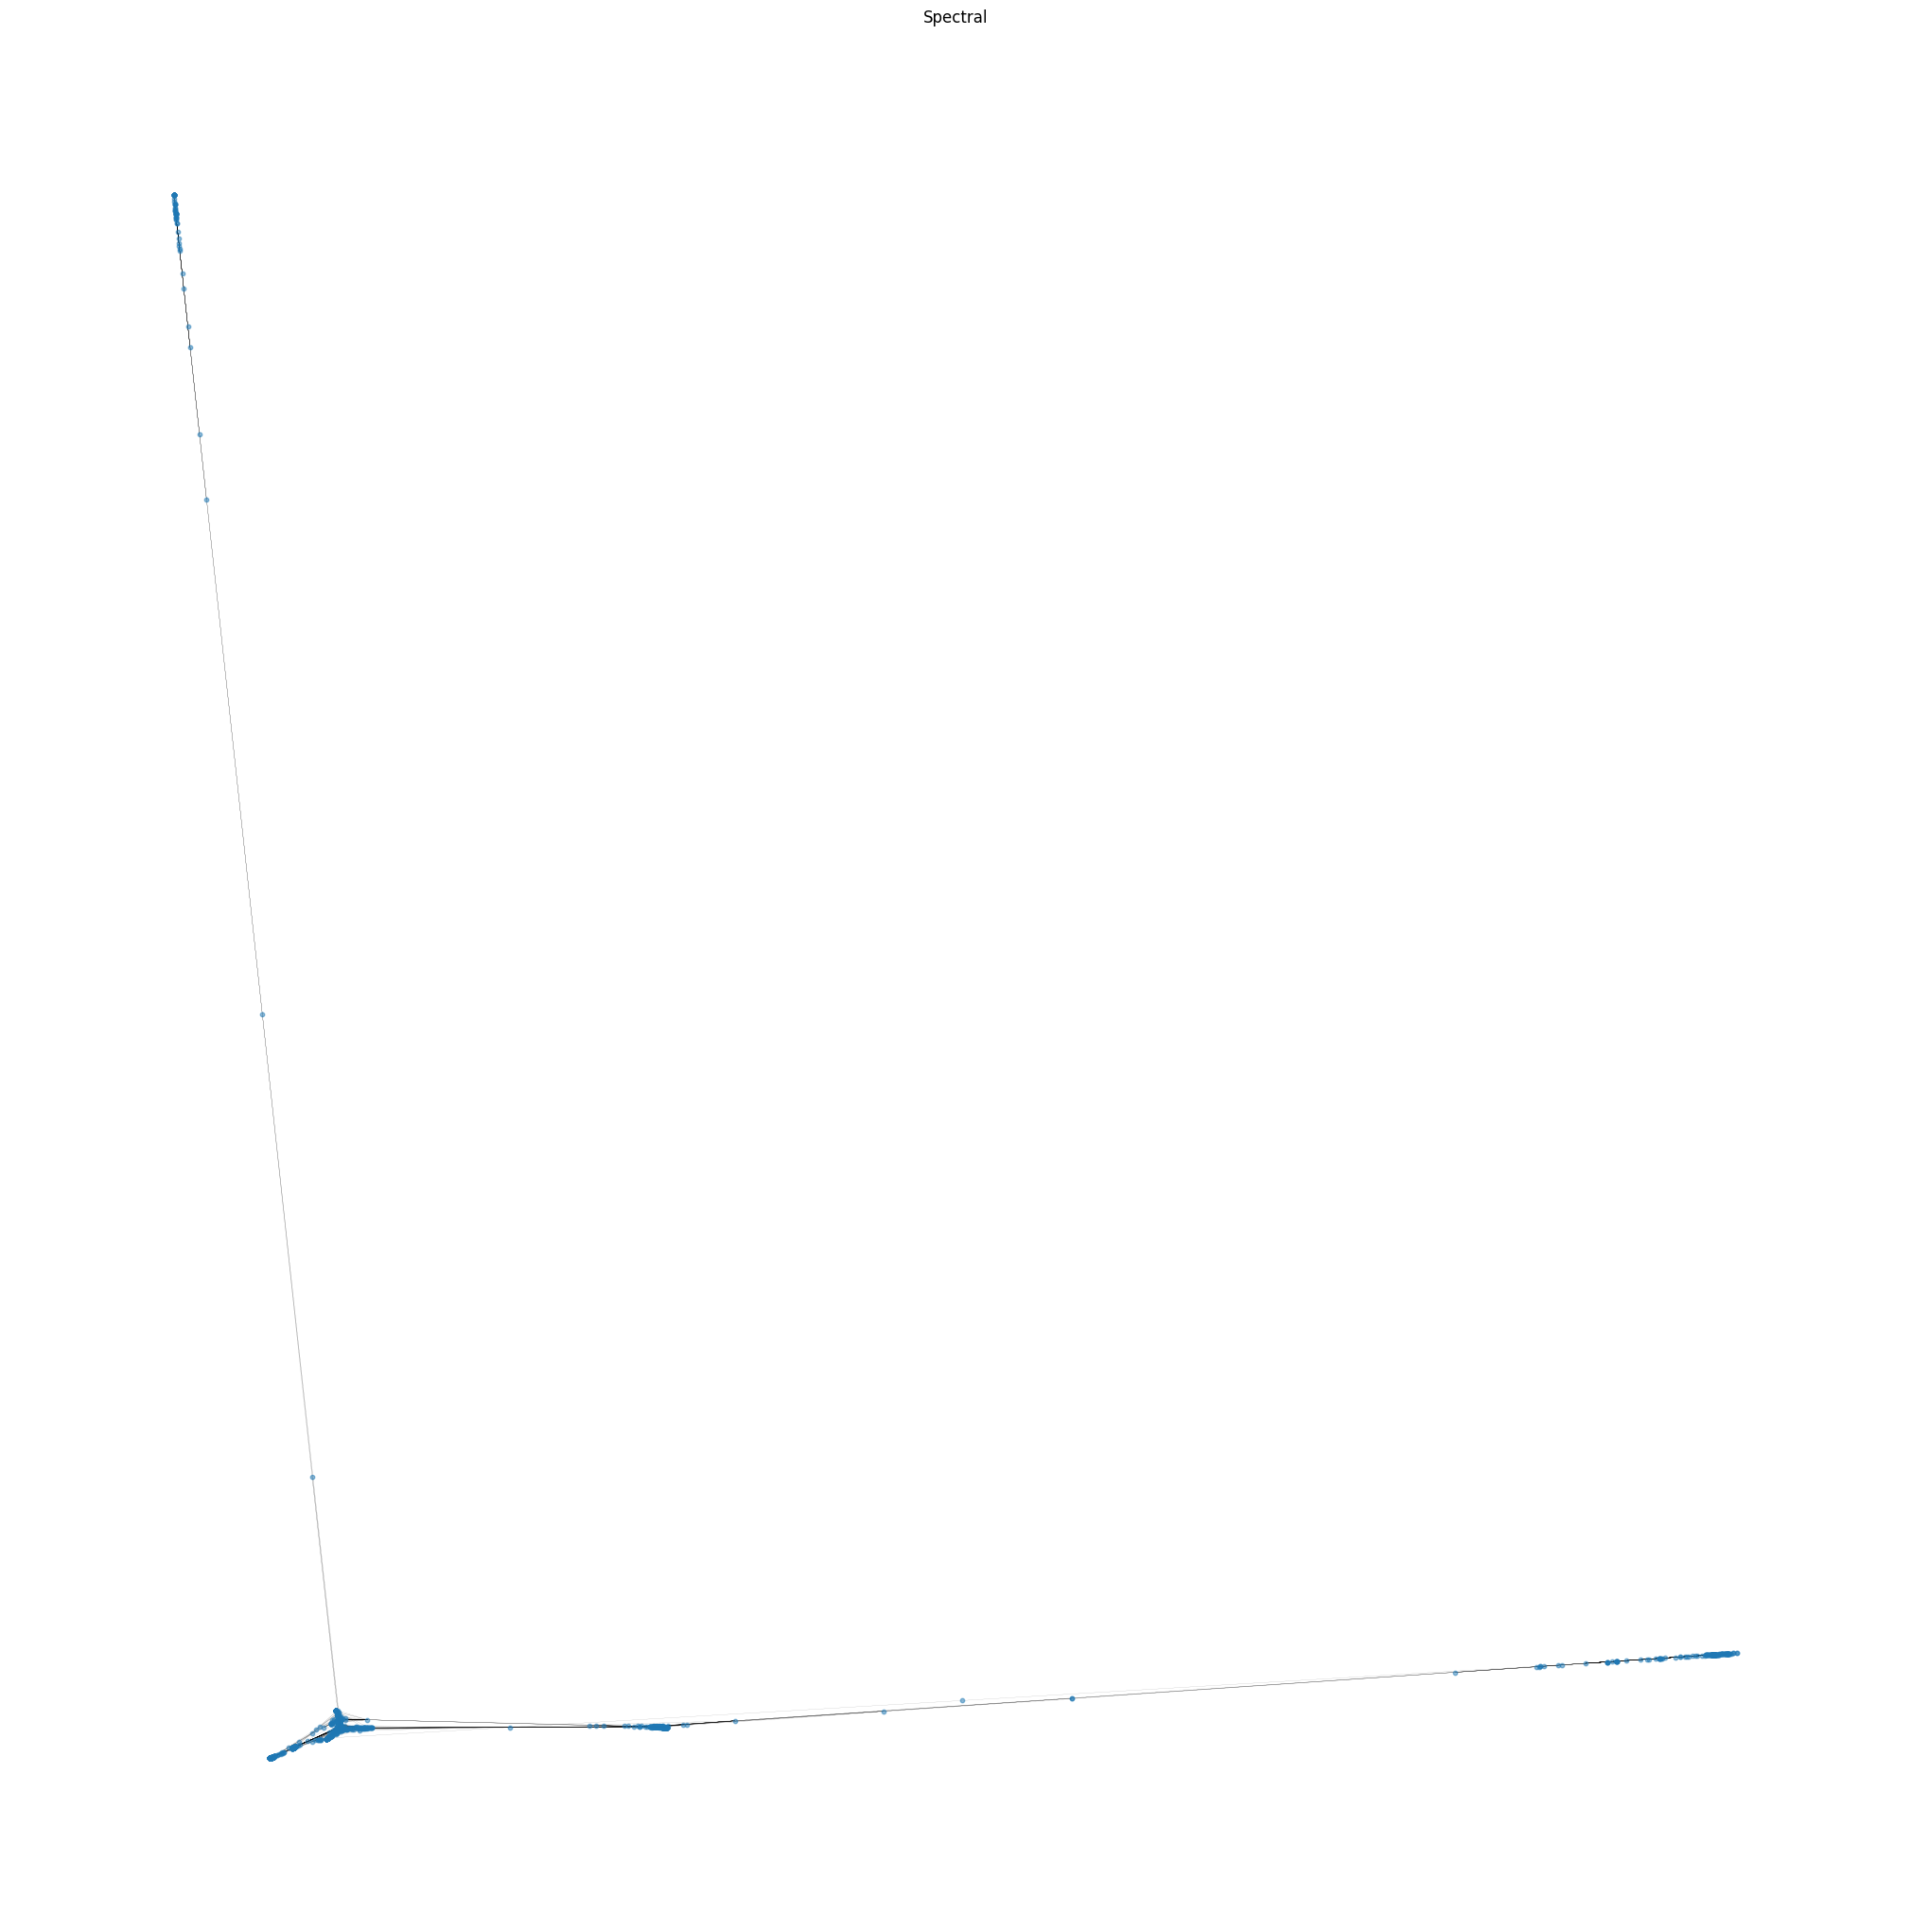

In [ ]:
plt.figure(figsize=(20, 20))
nx.draw(G, nx.spectral_layout(G), with_labels=False, node_size=10, width=0.1, alpha=0.5)
plt.title("Spectral")